<a href="https://colab.research.google.com/github/vstimpson/scientific-computing-projects/blob/main/Another_copy_of_Session6_IA_SciComp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<hr style="border:1px solid black"> </hr>

## Section 2. Submitting Your Work for Course Credit

### Fitting a set of data to a periodic function with a Fourier expansion


We will use matrix inversion to fit a set of data to a periodic function.

#### Fitting by matrix inversion

We want a set of data fitted by a function of the general form

\begin{equation*}
f(x) = \sum_k a_k g_k(x)
\end{equation*}

where each $g_k(x)$ is a predefined (normally simple) function of $x$,
and the coefficients $a_k$ need to be determined by fitting to the data.

In the case where we can describe a set of data by such $f(x)$,
and **where the number of data points is equal to the number of terms**,
we have a well-defined set of simultaneous equations of the form

\begin{equation*}
\begin{array}{c}
 f(x_1 ) = a_1 g_1 (x_1 ) + a_2 g_2 (x_1 ) +  \cdots  + a_n g_n (x_1 ) \\
 f(x_2 ) = a_1 g_1 (x_2 ) + a_2 g_2 (x_2 ) +  \cdots  + a_n g_n (x_2 ) \\
  \cdots  \\
 f(x_n ) = a_1 g_1 (x_n ) + a_2 g_2 (x_n ) +  \cdots  + a_n g_n (x_n ) \\
 \end{array}
\end{equation*}

in which everything is known except the coefficients $a_k$.
This can be expressed in matrix form:

\begin{equation}
\left( {\begin{array}{*{20}c}
   {f(x_1 )}  \\
   {f(x_2 )}  \\
    \vdots   \\
   {f(x_n )}  \\
\end{array}} \right) = \left( {\begin{array}{*{20}c}
   {g_1 (x_1 )} & {g_2 (x_1 )} &  \cdots  & {g_n (x_1 )}  \\
   {g_1 (x_2 )} & {g_2 (x_2 )} &  \cdots  & {g_n (x_2 )}  \\
    \vdots  &  \vdots  &  \ddots  &  \vdots   \\
   {g_1 (x_n )} & {g_2 (x_n )} &  \cdots  & {g_n (x_n )}  \\
\end{array}} \right) \times \left( {\begin{array}{*{20}c}
   {a_1 }  \\
   {a_2 }  \\
    \vdots   \\
   {a_n }  \\
\end{array}} \right)
\end{equation}

which can be written as

\begin{equation}
{\bf{f}} = {\bf{g}} \times {\bf{a}}
\end{equation}

Our aim is to find the coefficients in the column matrix $\mathbf{a}$, which are obtained from the matrix equation

\begin{equation}
{\bf{a}} = {\bf{g}}^{ - 1}  \times {\bf{f}}
\end{equation}

#### Fourier series for fitting a periodic function

  A periodic function $f(x)$ of period $a$, such that $f(x + N a)= f(x)$ for
any integer $N$, can be expanded using a so-called Fourier series

\begin{equation*}
\label{fourier}
f(x) = b_0 + \sum_{n=1}^{\infty} [ b_n \sin( n k x) + c_n \cos(n k x) ]
\end{equation*}
where $k = 2\pi/a$.

If we know the value of a periodic function in a set of points within a period,
we can obtain the smoothest periodic interpolation of those
points (such that the function does go through them) by truncating the sum
to the lowest values of $n$ needed, such that the number of variables coincides
with the number of data points for $f$.

Let us consider for instance 7 points, which will mean truncating the series
at $n=3$. The fitting function $f(x)$ is therefore

\begin{equation*}
f(x) = a_1 g_1(x) + a_2 g_2(x) + a_3 g_3(x) + \ldots  + a_7 g_7(x)
\end{equation*}

with the linear coefficients to be fitted

\begin{equation*}
a_1 = b_0 \; , \; a_2 = b_1 \, ; \; a_3 = c_1 \, ; \; a_4 = b_2 \, ; \; a_5 = c_2 \, ; \;
a_6 = b_3 \, ; \; a_7 = c_3 \, .
\end{equation*}

and the $g$ functions

\begin{align*}
g_1(x) &= 1 \\
g_2(x) &= \sin( k x) \\
g_3(x) &= \cos(k x) \\
g_4(x) &= \sin( 2k x) \\
g_5(x) &= \cos(2k x) \\
g_6(x) &= \sin( 3k x) \\
g_7(x) &= \cos(3k x)
\end{align*}

## The Submission

#### Start a new Jupyter notebook

Copy over the first python cell from this one for the preliminaries.

#### Generate and plot the data points

For a period $a=7$, generate arrays with
- The seven data points $x_j$ as $x = 0, 1, 2, \ldots , 6$.
- The $f(x_j)$, at random according to a flat distribution
  between 0 and 1.
  
Plot the generated data points

- with filled red circles ( ```plt.plot(x,f,'ro',markersize=12)```)
- for $x\in [-5,12]$ and $f \in [-0.3, 1.3]$ (`plt.xlim([-5,12]` etc.)
- using suitable ticks and labels

#### Generate the g matrix

**g** is the square matrix, defined as
$g_{ij} = g_i(x_j)$. First initialise it

```
G = np.ones((7,7))  # Initialise to ones (since first column will be ones anyway)
```
and then, column by column. You can use an auxiliary column array, as in

```
a = 7.
k = 2.*pi/a

auxi = np.sin(k*x)               # The x array is horizontal, sin(x)) as well
G[0:7,1] = np.transpose( auxi )  # Transpose the former to get it as column
auxi = np.cos(k*x)
G[0:7,2] = np.transpose( auxi )
...
```
etc., according to the definition of the $g_i(x)$ functions above.

#### Solve by matrix inversion

Now we solve the set of 7 linear equations by matrix inversion:

- Invert **g** using the `inv` function you have used above
  (the easiest bit to write, the critical and most expensive step in the   calculation).
- Check the inverse by matrix-multiply $\mathbf{g}^{-1} \mathbf{g}$.
- Obtain the needed coefficients as the **a** array,
  from the matrix multiplication

\begin{equation*}
\mathbf{a} = \mathbf{g}^{-1} \mathbf{f}
\end{equation*}

Remember that the set of $f$ values defined above for plotting was defined
on a single row matrix, that is $1\times 7$, but you need it as a $7\times 1$
column matrix.

#### Plot the fitted function alongside the data

Generate a set of 200 $x$ points between $-5$ and 12 (call the array ``xp``,
for instance).

Evaluate the fitted function on that array as follows
```
ff = a[0] + a[1]*np.sin(k*xp) + a[2]*np.cos(k*xp) ...
```
up to `... + a[6]*np.cos(3.*k*xp)`
(you could automatise it with a loop, but that comes in Session 7).

Plot ``ff`` versus ``xp`` with a black continuous line of thickness 2pt,
in a plot like the former one, alongside the filled red circles
of the data points.

Notice that every time you run the notebook you get a
different set of points, but, if correct, the black line will
go through all of the points every time.

In [ ]:
# Importing needed libraries
import numpy as np
import matplotlib.pyplot as plt
from numpy import pi
from numpy.random import rand, randn   # It generates random matrices
from numpy.linalg import inv # Matrix inversion routine from the linear algbra package in NumPy
from numpy.linalg import eig # linear algebra eigen-solver
from numpy.linalg import det # determinant of a matrix


np.set_printoptions(suppress=True) # makes tiny values appear as zero
np.set_printoptions(precision=4)   # number of digits in floats (or longfloats)
#np.set_printoptions(formatter={'float_kind':"{:.2f}"})
#np.set_printoptions()

font16 = {'family': 'times new roman',   # Fonts for plot labels
          'color':  'black',
          'weight': 'normal',
          'size': 16,
          }
font20 = {'family': 'times new roman',
          'color':  'black',
          'weight': 'normal',
          'size': 20,
          }

In [ ]:
a = np.array([0,1,2,3,4,5,6])
print (a)
f=np.random.rand(7)
print (f)

[0 1 2 3 4 5 6]
[0.746  0.6798 0.1043 0.5337 0.6684 0.9786 0.742 ]


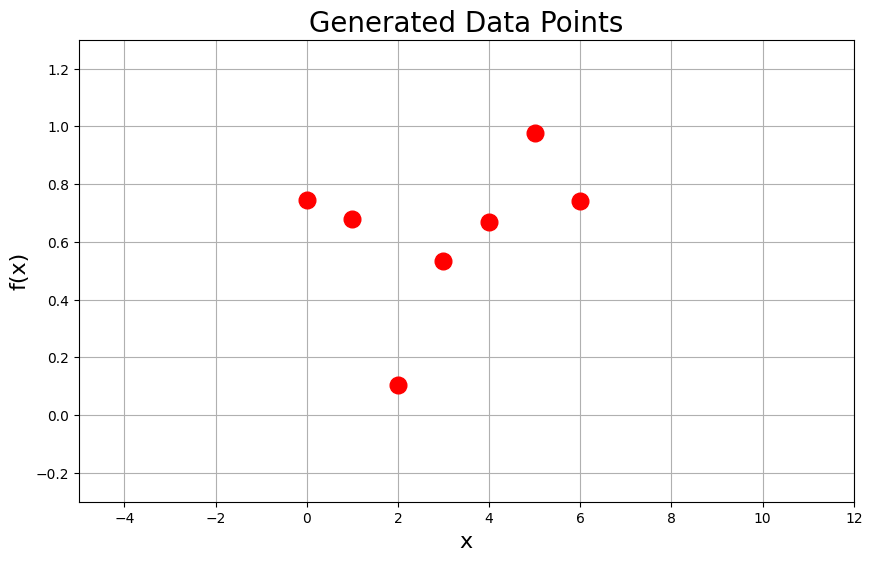

In [ ]:
plt.figure(figsize=(10,6)) # Optional: Make the plot larger
plt.plot(x,f,'ro',markersize=12)
plt.xlim([-5,12])
plt.ylim([-0.3, 1.3])
plt.xlabel('x', fontdict=font16)
plt.ylabel('f(x)', fontdict=font16)
plt.title('Generated Data Points', fontdict=font20)
plt.grid(True)
plt.show()

In [ ]:
G = np.ones((7,7))
a = 7.
k = 2.*pi/a
x = np.array([0,1,2,3,4,5,6])

# g_1(x) = 1, already set by np.ones

# g_2(x) = sin(k*x)
auxi = np.sin(k*x)
G[0:7,1] = np.transpose(auxi)

# g_3(x) = cos(k*x)
auxi = np.cos(k*x)
G[0:7,2] = np.transpose(auxi)

# g_4(x) = sin(2*k*x)
auxi = np.sin(2*k*x)
G[0:7,3] = np.transpose(auxi)

# g_5(x) = cos(2*k*x)
auxi = np.cos(2*k*x)
G[0:7,4] = np.transpose(auxi)

# g_6(x) = sin(3*k*x)
auxi = np.sin(3*k*x)
G[0:7,5] = np.transpose(auxi)

# g_7(x) = cos(3*k*x)
auxi = np.cos(3*k*x)
G[0:7,6] = np.transpose(auxi)

print("G matrix:\n", G)

G matrix:
 [[ 1.      0.      1.      0.      1.      0.      1.    ]
 [ 1.      0.7818  0.6235  0.9749 -0.2225  0.4339 -0.901 ]
 [ 1.      0.9749 -0.2225 -0.4339 -0.901  -0.7818  0.6235]
 [ 1.      0.4339 -0.901  -0.7818  0.6235  0.9749 -0.2225]
 [ 1.     -0.4339 -0.901   0.7818  0.6235 -0.9749 -0.2225]
 [ 1.     -0.9749 -0.2225  0.4339 -0.901   0.7818  0.6235]
 [ 1.     -0.7818  0.6235 -0.9749 -0.2225 -0.4339 -0.901 ]]


In [ ]:
# Reshape f to be a column vector
f_col = f.reshape(7, 1)

# Invert G matrix
G_inv = inv(G)

# Check the inverse by matrix-multiply G_inv @ G
print("G_inverse @ G:\n", G_inv @ G)

# Obtain the coefficients 'a'
a_coeffs = G_inv @ f_col
print("\nCoefficients a:\n", a_coeffs)

G_inverse @ G:
 [[ 1.  0.  0. -0. -0.  0. -0.]
 [ 0.  1. -0.  0. -0.  0. -0.]
 [-0. -0.  1.  0.  0. -0. -0.]
 [ 0.  0. -0.  1. -0. -0. -0.]
 [ 0. -0. -0.  0.  1.  0.  0.]
 [-0.  0.  0.  0.  0.  1. -0.]
 [ 0.  0.  0.  0. -0.  0.  1.]]

Coefficients a:
 [[ 0.6361]
 [-0.2741]
 [ 0.0881]
 [ 0.1212]
 [ 0.0581]
 [ 0.1501]
 [-0.0364]]


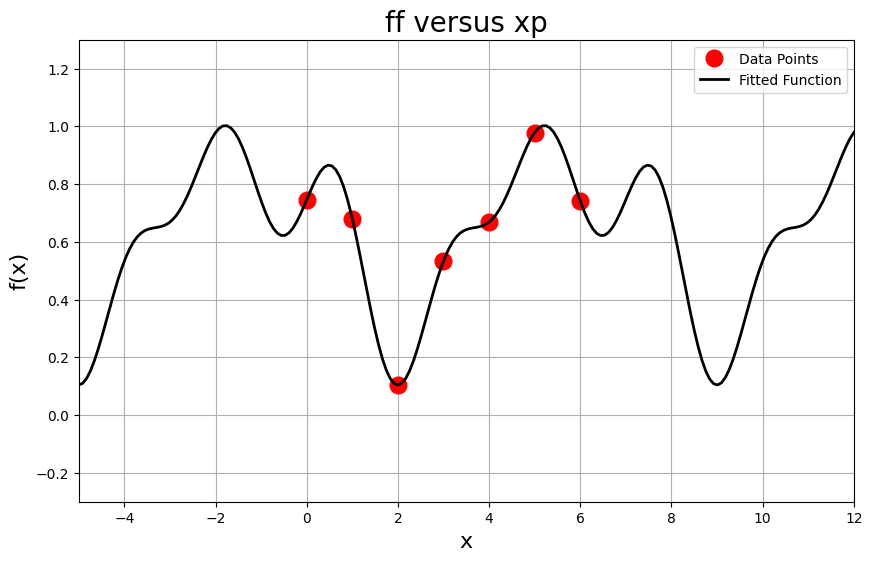

In [ ]:
# Generate a set of 200 x points for plotting the fitted function
xp = np.linspace(-5, 12, 200)

# Evaluate the fitted function on the xp array
# f(x) = a[0]*g1(x) + a[1]*g2(x) + ... + a[6]*g7(x)
# g1(x) = 1, g2(x) = sin(k*x), g3(x) = cos(k*x), etc.

ff = a_coeffs[0] * 1 \
     + a_coeffs[1] * np.sin(k * xp) \
     + a_coeffs[2] * np.cos(k * xp) \
     + a_coeffs[3] * np.sin(2 * k * xp) \
     + a_coeffs[4] * np.cos(2 * k * xp) \
     + a_coeffs[5] * np.sin(3 * k * xp) \
     + a_coeffs[6] * np.cos(3 * k * xp)

# Plot the fitted function alongside the data
plt.figure(figsize=(10,6))
plt.plot(x, f, 'ro', markersize=12, label='Data Points')
plt.plot(xp, ff, 'k-', linewidth=2, label='Fitted Function')
plt.xlim([-5,12])
plt.ylim([-0.3, 1.3])
plt.xlabel('x', fontdict=font16)
plt.ylabel('f(x)', fontdict=font16)
plt.title('ff versus xp', fontdict=font20)
plt.grid(True)
plt.legend()
plt.show()